# 02 DAG and Discovery Review

Review-only notebook for the hand-built DAG and saved reduced causal discovery outputs. This notebook does not run causal discovery; use `make run-discovery` to refresh artifacts.

In [1]:
from pathlib import Path
import json

import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

from oulad_causal.config import DOCS_DIR, FIGURES_DIR, PROCESSED_DATA_DIR
from oulad_causal.dag import (
    DAG_FIGURE_PATH,
    DAG_VARIABLE_AVAILABILITY_PATH,
    DAG_YAML_PATH,
    discovery_variable_list,
    primary_dag_spec,
    recommended_baseline_adjustment_set,
)
from oulad_causal.discovery import (
    DISCOVERY_COMBINED_EDGES_PATH,
    DISCOVERY_COMPARISON_PATH,
    DISCOVERY_METADATA_PATH,
    DISCOVERY_PREPROCESSING_MAP_PATH,
    DISCOVERY_STABILITY_PATH,
    DISCOVERY_SUMMARY_PATH,
    select_discovery_variables,
)

## Hand-Built DAG

The saved DAG is the domain-informed baseline for identification. Discovery output is compared against this graph rather than treated as definitive truth.

In [2]:
if DAG_YAML_PATH.exists():
    with DAG_YAML_PATH.open(encoding="utf-8") as handle:
        dag_spec = yaml.safe_load(handle)
else:
    dag_spec = primary_dag_spec()

pd.DataFrame(dag_spec["nodes"])[["id", "label", "role", "observed", "cohort_columns"]]

,id,label,role,observed,cohort_columns
0,gender,Gender,confounder,True,[baseline_gender]
1,region,Region,confounder,True,[baseline_region]
2,age_band,Age band,confounder,True,[baseline_age_band]
3,highest_education,Highest education,confounder,True,[baseline_highest_education]
4,imd_band,IMD band,confounder,True,[baseline_imd_band]
5,disability,Disability,confounder,True,[baseline_disability]
6,prior_attempts,Prior attempts,confounder,True,[baseline_num_of_prev_attempts]
7,studied_credits,Studied credits,confounder,True,[baseline_studied_credits]
8,registration_timing,Registration timing,confounder,True,"[baseline_date_registration, baseline_missing_..."
9,module_presentation,Module presentation,confounder,True,"[baseline_module_presentation, baseline_module..."


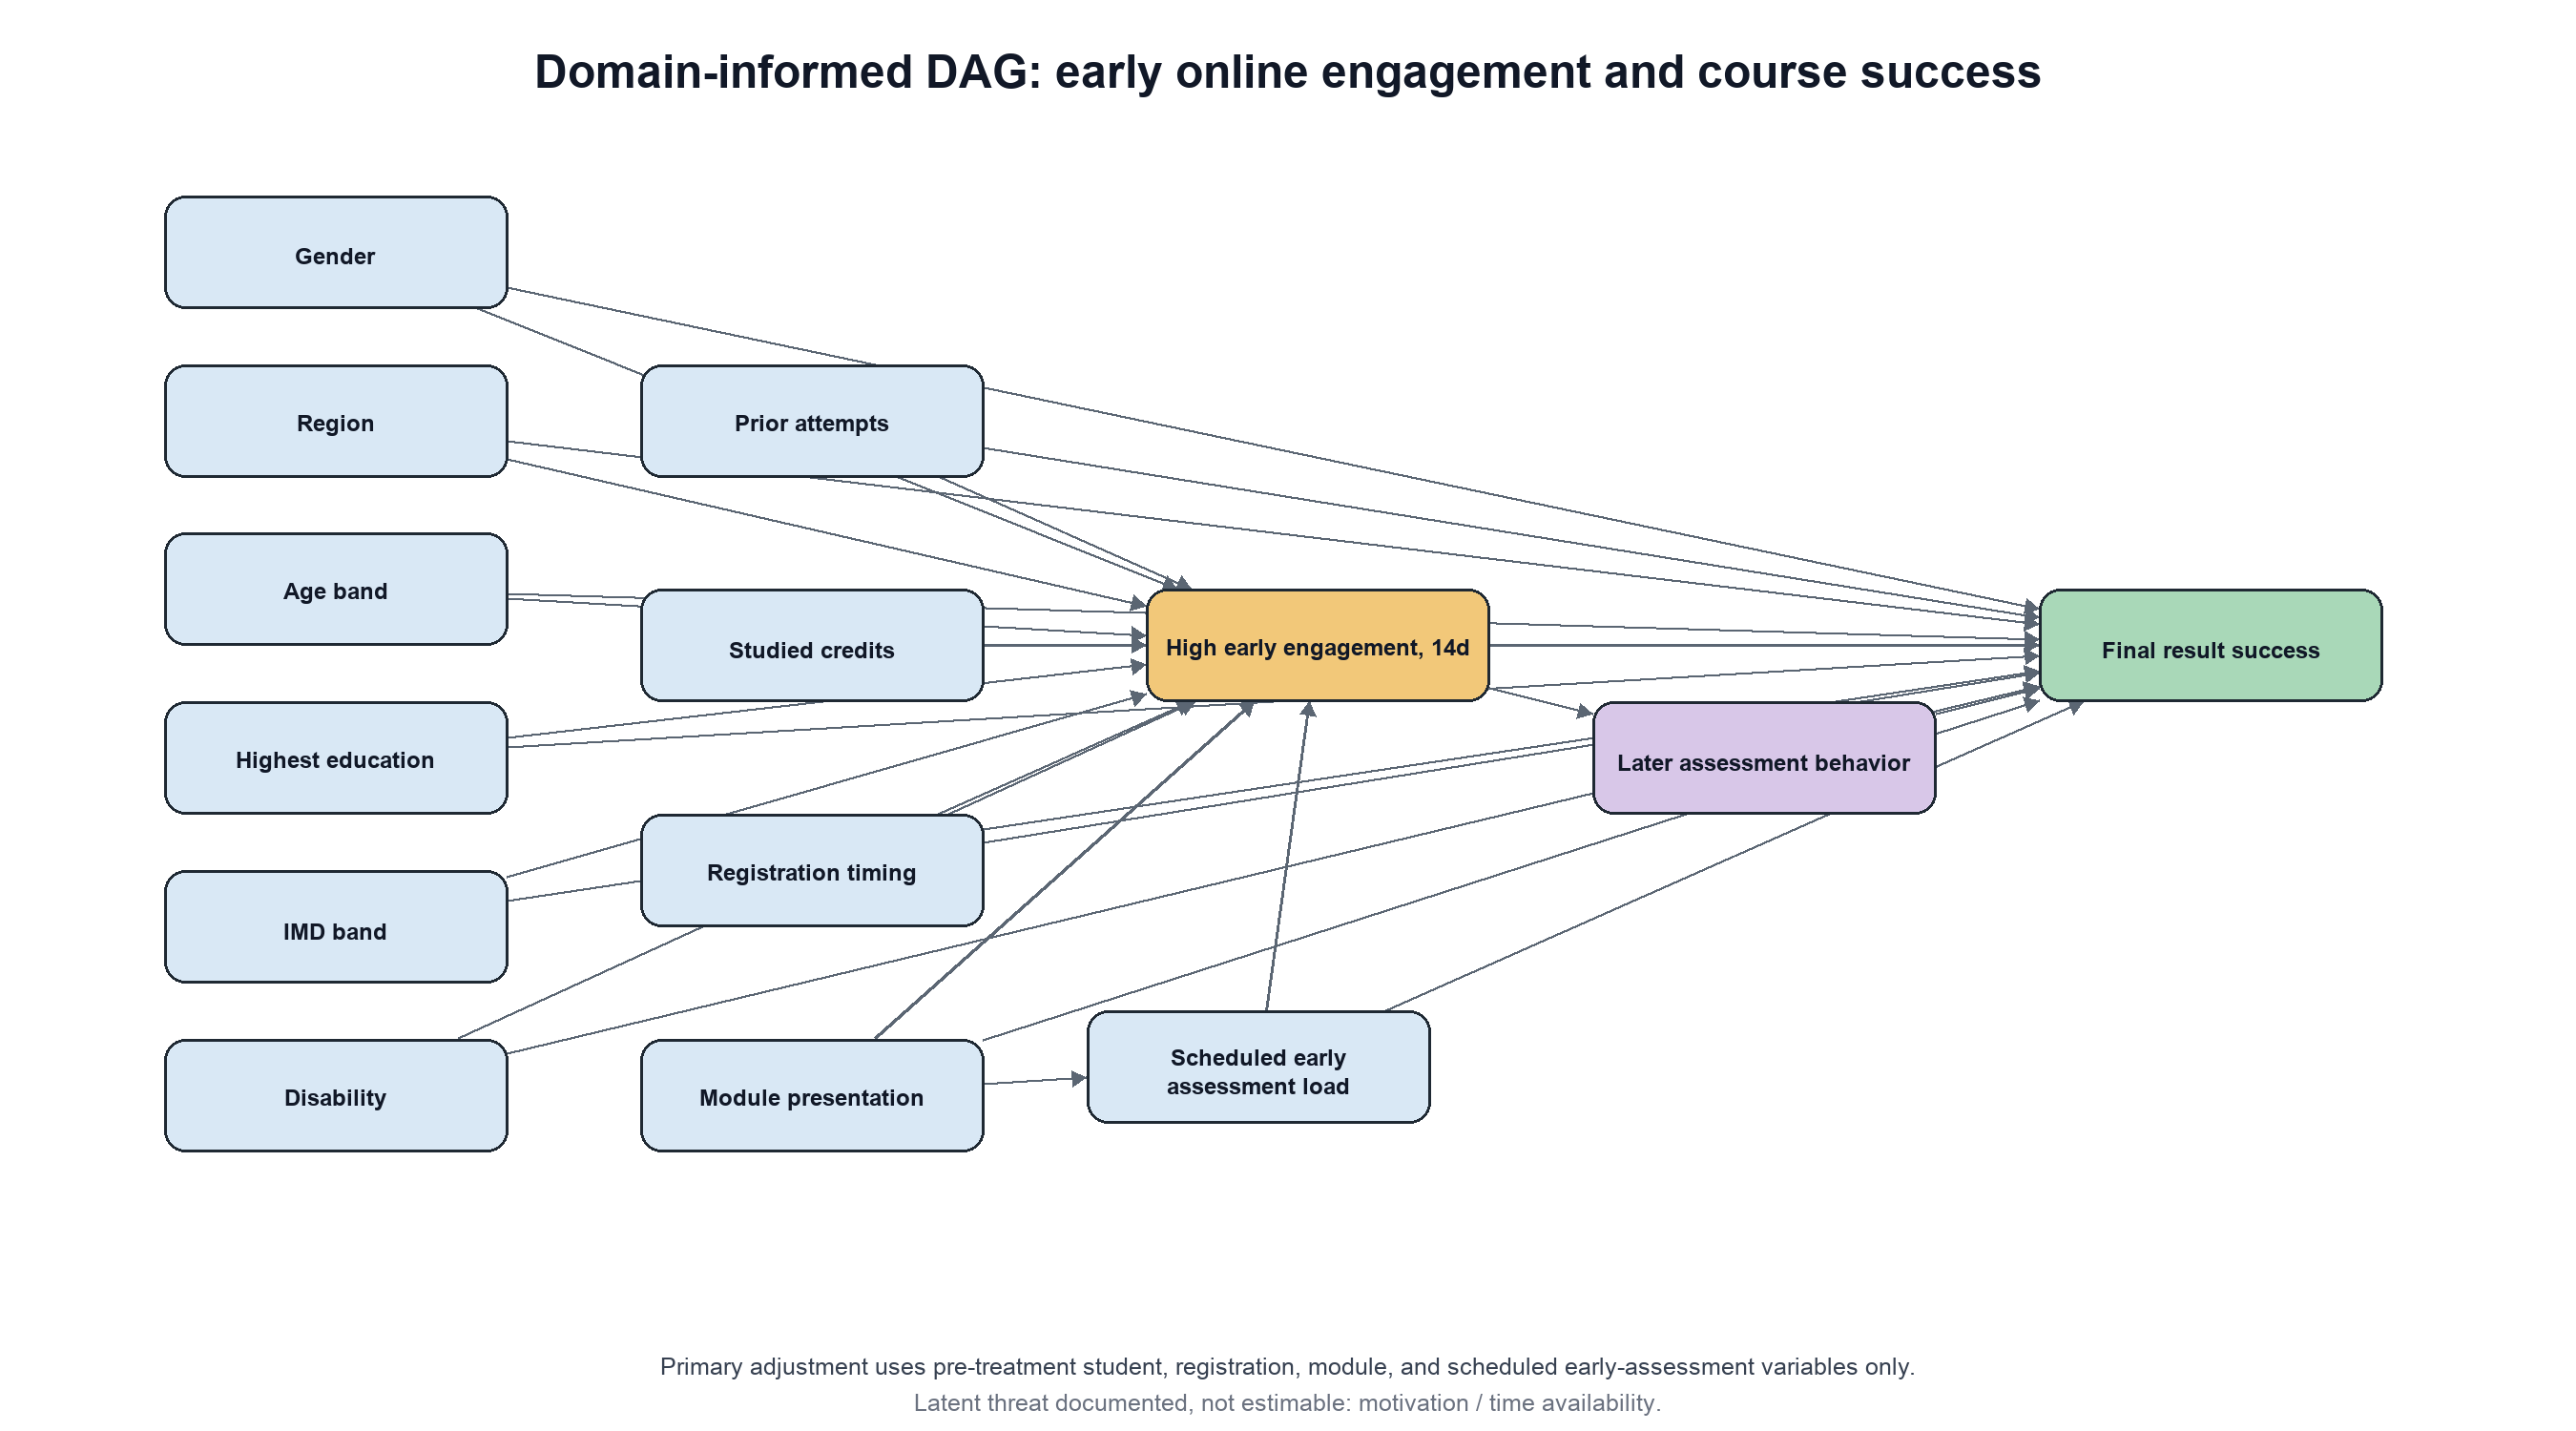

In [3]:
if DAG_FIGURE_PATH.exists():
    display(Image(filename=str(DAG_FIGURE_PATH)))
else:
    print(f"DAG figure not found yet: {DAG_FIGURE_PATH}")

## Primary Adjustment Set

In [4]:
pd.Series(recommended_baseline_adjustment_set(), name="recommended_baseline_adjustment_column").to_frame()

,recommended_baseline_adjustment_column
0,baseline_gender
1,baseline_region
2,baseline_age_band
3,baseline_highest_education
4,baseline_imd_band
5,baseline_disability
6,baseline_num_of_prev_attempts
7,baseline_studied_credits
8,baseline_date_registration
9,baseline_missing_date_registration


## Cohort Metadata and Variable Availability

In [5]:
summary_path = PROCESSED_DATA_DIR / "cohort_summary.json"
with summary_path.open(encoding="utf-8") as handle:
    cohort_summary = json.load(handle)

cohort_summary["cohort_size"], cohort_summary["primary_window_days"], cohort_summary["exclusion_counts"]

(28128,
 14,
 [{'stage': 'student_info_records', 'excluded_count': 0},
  {'stage': 'after_required_table_joins', 'excluded_count': 0},
  {'stage': 'after_primary_treatment_eligibility', 'excluded_count': 4465}])

In [6]:
if DAG_VARIABLE_AVAILABILITY_PATH.exists():
    display(pd.read_csv(DAG_VARIABLE_AVAILABILITY_PATH))
else:
    print(f"Saved availability table not found yet: {DAG_VARIABLE_AVAILABILITY_PATH}")

,source,name,role,cohort_columns,available,missing_columns
0,dag_node,gender,confounder,baseline_gender,True,NaN
1,dag_node,region,confounder,baseline_region,True,NaN
2,dag_node,age_band,confounder,baseline_age_band,True,NaN
3,dag_node,highest_education,confounder,baseline_highest_education,True,NaN
4,dag_node,imd_band,confounder,baseline_imd_band,True,NaN
5,dag_node,disability,confounder,baseline_disability,True,NaN
6,dag_node,prior_attempts,confounder,baseline_num_of_prev_attempts,True,NaN
7,dag_node,studied_credits,confounder,baseline_studied_credits,True,NaN
8,dag_node,registration_timing,confounder,"baseline_date_registration, baseline_missing_d...",True,NaN
9,dag_node,module_presentation,confounder,"baseline_module_presentation, baseline_module_...",True,NaN


## Discovery Variable Set

The implemented workflow uses a bounded 12-variable set for PC, FCI, and GES. It excludes later assessment behavior and the continuous engagement z-score to avoid a deterministic score-threshold relationship dominating discovery.

In [7]:
pd.Series(select_discovery_variables(), name="implemented_discovery_variable").to_frame()

,implemented_discovery_variable
0,baseline_gender
1,baseline_age_band
2,baseline_highest_education
3,baseline_imd_band
4,baseline_disability
5,baseline_num_of_prev_attempts
6,baseline_studied_credits
7,baseline_registered_before_start
8,baseline_module_presentation_length
9,early_assessment_weight_14d


## Discovery Run Metadata

In [8]:
if DISCOVERY_METADATA_PATH.exists():
    with DISCOVERY_METADATA_PATH.open(encoding="utf-8") as handle:
        discovery_metadata = json.load(handle)
    display(pd.DataFrame(discovery_metadata["methods"]).T)
    display(discovery_metadata.get("artifacts", {}))
else:
    print(f"Discovery metadata not found yet: {DISCOVERY_METADATA_PATH}")

,status,seconds,edge_count,stability_run
pc,success,5.369,27,False
fci,success,3.788,25,False
ges,success,10.017,19,False


{'analysis_data': '/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_analysis_data.parquet',
 'preprocessing_map': '/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_preprocessing_map.json',
 'combined_edges': '/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_edges.csv',
 'edges_pc': '/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_edges_pc.csv',
 'edges_fci': '/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_edges_fci.csv',
 'edges_ges': '/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_edges_ges.csv',
 'adjacency_pc': '/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-

## Discovery Preprocessing

In [9]:
if DISCOVERY_PREPROCESSING_MAP_PATH.exists():
    with DISCOVERY_PREPROCESSING_MAP_PATH.open(encoding="utf-8") as handle:
        preprocessing = json.load(handle)
    display(pd.DataFrame(preprocessing["columns"]).T)
else:
    print(f"Preprocessing map not found yet: {DISCOVERY_PREPROCESSING_MAP_PATH}")

,preprocessing,mapping,missing_count,missing_code,requested_bins,actual_bins,bin_intervals,column
baseline_gender,nominal_category_codes,"{'F': 0, 'M': 1}",0,-1,NaN,NaN,NaN,NaN
baseline_age_band,explicit_ordinal,"{'0-35': 0, '35-55': 1, '55<=': 2}",0,-1,NaN,NaN,NaN,NaN
baseline_highest_education,explicit_ordinal,"{'No Formal quals': 0, 'Lower Than A Level': 1...",0,-1,NaN,NaN,NaN,NaN
baseline_imd_band,explicit_ordinal_imd_lower_bound,"{'0-10%': 0, '10-20': 1, '20-30%': 2, '30-40%'...",0,-1,NaN,NaN,NaN,NaN
baseline_disability,nominal_category_codes,"{'N': 0, 'Y': 1}",0,-1,NaN,NaN,NaN,NaN
baseline_num_of_prev_attempts,ordered_numeric_state_codes,"{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': ...",0,-1,NaN,NaN,NaN,NaN
baseline_studied_credits,quantile_bins,NaN,0,-1,4,3,"[(29.999, 60.0], (60.0, 90.0], (90.0, 630.0]]",baseline_studied_credits
baseline_registered_before_start,binary_integer_state,"{'0': 0, '1': 1}",0,-1,NaN,NaN,NaN,NaN
baseline_module_presentation_length,ordered_numeric_state_codes,"{'234': 0, '240': 1, '241': 2, '261': 3, '262'...",0,-1,NaN,NaN,NaN,NaN
early_assessment_weight_14d,ordered_numeric_state_codes,"{'0': 0, '5': 1}",0,-1,NaN,NaN,NaN,NaN


## Discovery Edge Lists

In [10]:
if DISCOVERY_COMBINED_EDGES_PATH.exists():
    edges = pd.read_csv(DISCOVERY_COMBINED_EDGES_PATH)
    display(edges)
    display(edges.groupby("method").size().rename("edge_count").to_frame())
else:
    print(f"Combined discovery edge list not found yet: {DISCOVERY_COMBINED_EDGES_PATH}")

,method,source,target,endpoint_source,endpoint_target,edge_type,directed_source,directed_target,is_directed,skeleton_key
0,pc,baseline_gender,baseline_age_band,TAIL,ARROW,baseline_gender --> baseline_age_band,baseline_gender,baseline_age_band,True,baseline_age_band||baseline_gender
1,pc,baseline_gender,baseline_highest_education,TAIL,ARROW,baseline_gender --> baseline_highest_education,baseline_gender,baseline_highest_education,True,baseline_gender||baseline_highest_education
2,pc,baseline_imd_band,baseline_gender,TAIL,ARROW,baseline_imd_band --> baseline_gender,baseline_imd_band,baseline_gender,True,baseline_gender||baseline_imd_band
3,pc,baseline_studied_credits,baseline_gender,TAIL,ARROW,baseline_studied_credits --> baseline_gender,baseline_studied_credits,baseline_gender,True,baseline_gender||baseline_studied_credits
4,pc,baseline_gender,baseline_module_presentation_length,TAIL,ARROW,baseline_gender --> baseline_module_presentati...,baseline_gender,baseline_module_presentation_length,True,baseline_gender||baseline_module_presentation_...
...,...,...,...,...,...,...,...,...,...,...
66,ges,baseline_module_presentation_length,baseline_studied_credits,TAIL,ARROW,baseline_module_presentation_length --> baseli...,baseline_module_presentation_length,baseline_studied_credits,True,baseline_module_presentation_length||baseline_...
67,ges,treatment_high_engagement_14d_median,baseline_registered_before_start,TAIL,ARROW,treatment_high_engagement_14d_median --> basel...,treatment_high_engagement_14d_median,baseline_registered_before_start,True,baseline_registered_before_start||treatment_hi...
68,ges,baseline_module_presentation_length,early_assessment_weight_14d,TAIL,ARROW,baseline_module_presentation_length --> early_...,baseline_module_presentation_length,early_assessment_weight_14d,True,baseline_module_presentation_length||early_ass...
69,ges,outcome_success,baseline_module_presentation_length,TAIL,ARROW,outcome_success --> baseline_module_presentati...,outcome_success,baseline_module_presentation_length,True,baseline_module_presentation_length||outcome_s...


,edge_count
method,
fci,25
ges,19
pc,27


## Stability Checks

In [11]:
if DISCOVERY_STABILITY_PATH.exists():
    stability = pd.read_csv(DISCOVERY_STABILITY_PATH)
    display(stability.sort_values(["edge_frequency", "method"], ascending=[False, True]).head(30))
else:
    print(f"Discovery stability table not found yet: {DISCOVERY_STABILITY_PATH}")

,method,var_a,var_b,edge_frequency,directed_a_to_b_frequency,directed_b_to_a_frequency,repetitions_attempted,repetitions_succeeded,failures
45,fci,baseline_age_band,baseline_highest_education,1.00,0.00,0.00,20,20,0
53,fci,baseline_gender,baseline_module_presentation_length,1.00,0.00,0.05,20,20,0
55,fci,baseline_highest_education,baseline_imd_band,1.00,0.40,0.00,20,20,0
60,fci,baseline_module_presentation_length,early_assessment_weight_14d,1.00,0.40,0.00,20,20,0
63,fci,baseline_num_of_prev_attempts,baseline_studied_credits,1.00,0.30,0.00,20,20,0
67,fci,outcome_success,treatment_high_engagement_14d_median,1.00,0.05,0.00,20,20,0
31,ges,baseline_gender,baseline_module_presentation_length,1.00,0.05,0.00,20,20,0
36,ges,baseline_module_presentation_length,early_assessment_weight_14d,1.00,0.05,0.00,20,20,0
43,ges,outcome_success,treatment_high_engagement_14d_median,1.00,0.20,0.10,20,20,0
1,pc,baseline_age_band,baseline_highest_education,1.00,0.00,0.70,20,20,0


## Hand-DAG Comparison

In [12]:
if DISCOVERY_COMPARISON_PATH.exists():
    comparison = pd.read_csv(DISCOVERY_COMPARISON_PATH)
    display(comparison)
    if not comparison.empty:
        display(comparison.groupby(["method", "in_hand_skeleton", "in_hand_directed"]).size().rename("count").reset_index())
else:
    print(f"Discovery comparison table not found yet: {DISCOVERY_COMPARISON_PATH}")

,method,source,target,endpoint_source,endpoint_target,edge_type,directed_source,directed_target,is_directed,skeleton_key,source_dag_node,target_dag_node,source_role,target_role,in_hand_skeleton,hand_direction,in_hand_directed
0,pc,baseline_gender,baseline_age_band,TAIL,ARROW,baseline_gender --> baseline_age_band,baseline_gender,baseline_age_band,True,baseline_age_band||baseline_gender,gender,age_band,confounder,confounder,False,NaN,False
1,pc,baseline_gender,baseline_highest_education,TAIL,ARROW,baseline_gender --> baseline_highest_education,baseline_gender,baseline_highest_education,True,baseline_gender||baseline_highest_education,gender,highest_education,confounder,confounder,False,NaN,False
2,pc,baseline_imd_band,baseline_gender,TAIL,ARROW,baseline_imd_band --> baseline_gender,baseline_imd_band,baseline_gender,True,baseline_gender||baseline_imd_band,imd_band,gender,confounder,confounder,False,NaN,False
3,pc,baseline_studied_credits,baseline_gender,TAIL,ARROW,baseline_studied_credits --> baseline_gender,baseline_studied_credits,baseline_gender,True,baseline_gender||baseline_studied_credits,studied_credits,gender,confounder,confounder,False,NaN,False
4,pc,baseline_gender,baseline_module_presentation_length,TAIL,ARROW,baseline_gender --> baseline_module_presentati...,baseline_gender,baseline_module_presentation_length,True,baseline_gender||baseline_module_presentation_...,gender,module_presentation,confounder,confounder,False,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,hand_dag_missing_from_discovery,baseline_module_presentation_length,treatment_high_engagement_14d_median,TAIL,ARROW,baseline_module_presentation_length --> treatm...,baseline_module_presentation_length,treatment_high_engagement_14d_median,True,baseline_module_presentation_length||treatment...,module_presentation,early_engagement_14d,confounder,treatment,True,baseline_module_presentation_length -> treatme...,False
77,hand_dag_missing_from_discovery,baseline_registered_before_start,outcome_success,TAIL,ARROW,baseline_registered_before_start --> outcome_s...,baseline_registered_before_start,outcome_success,True,baseline_registered_before_start||outcome_success,registration_timing,final_result_success,confounder,outcome,True,baseline_registered_before_start -> outcome_su...,False
78,hand_dag_missing_from_discovery,baseline_studied_credits,treatment_high_engagement_14d_median,TAIL,ARROW,baseline_studied_credits --> treatment_high_en...,baseline_studied_credits,treatment_high_engagement_14d_median,True,baseline_studied_credits||treatment_high_engag...,studied_credits,early_engagement_14d,confounder,treatment,True,baseline_studied_credits -> treatment_high_eng...,False
79,hand_dag_missing_from_discovery,early_assessment_weight_14d,outcome_success,TAIL,ARROW,early_assessment_weight_14d --> outcome_success,early_assessment_weight_14d,outcome_success,True,early_assessment_weight_14d||outcome_success,early_assessment_load,final_result_success,confounder,outcome,True,early_assessment_weight_14d -> outcome_success,False


,method,in_hand_skeleton,in_hand_directed,count
0,fci,False,False,15
1,fci,True,False,9
2,fci,True,True,1
3,ges,False,False,9
4,ges,True,False,6
5,ges,True,True,4
6,hand_dag_missing_from_discovery,True,False,10
7,pc,False,False,17
8,pc,True,False,8
9,pc,True,True,2


## Discovery Graph Figures

PC


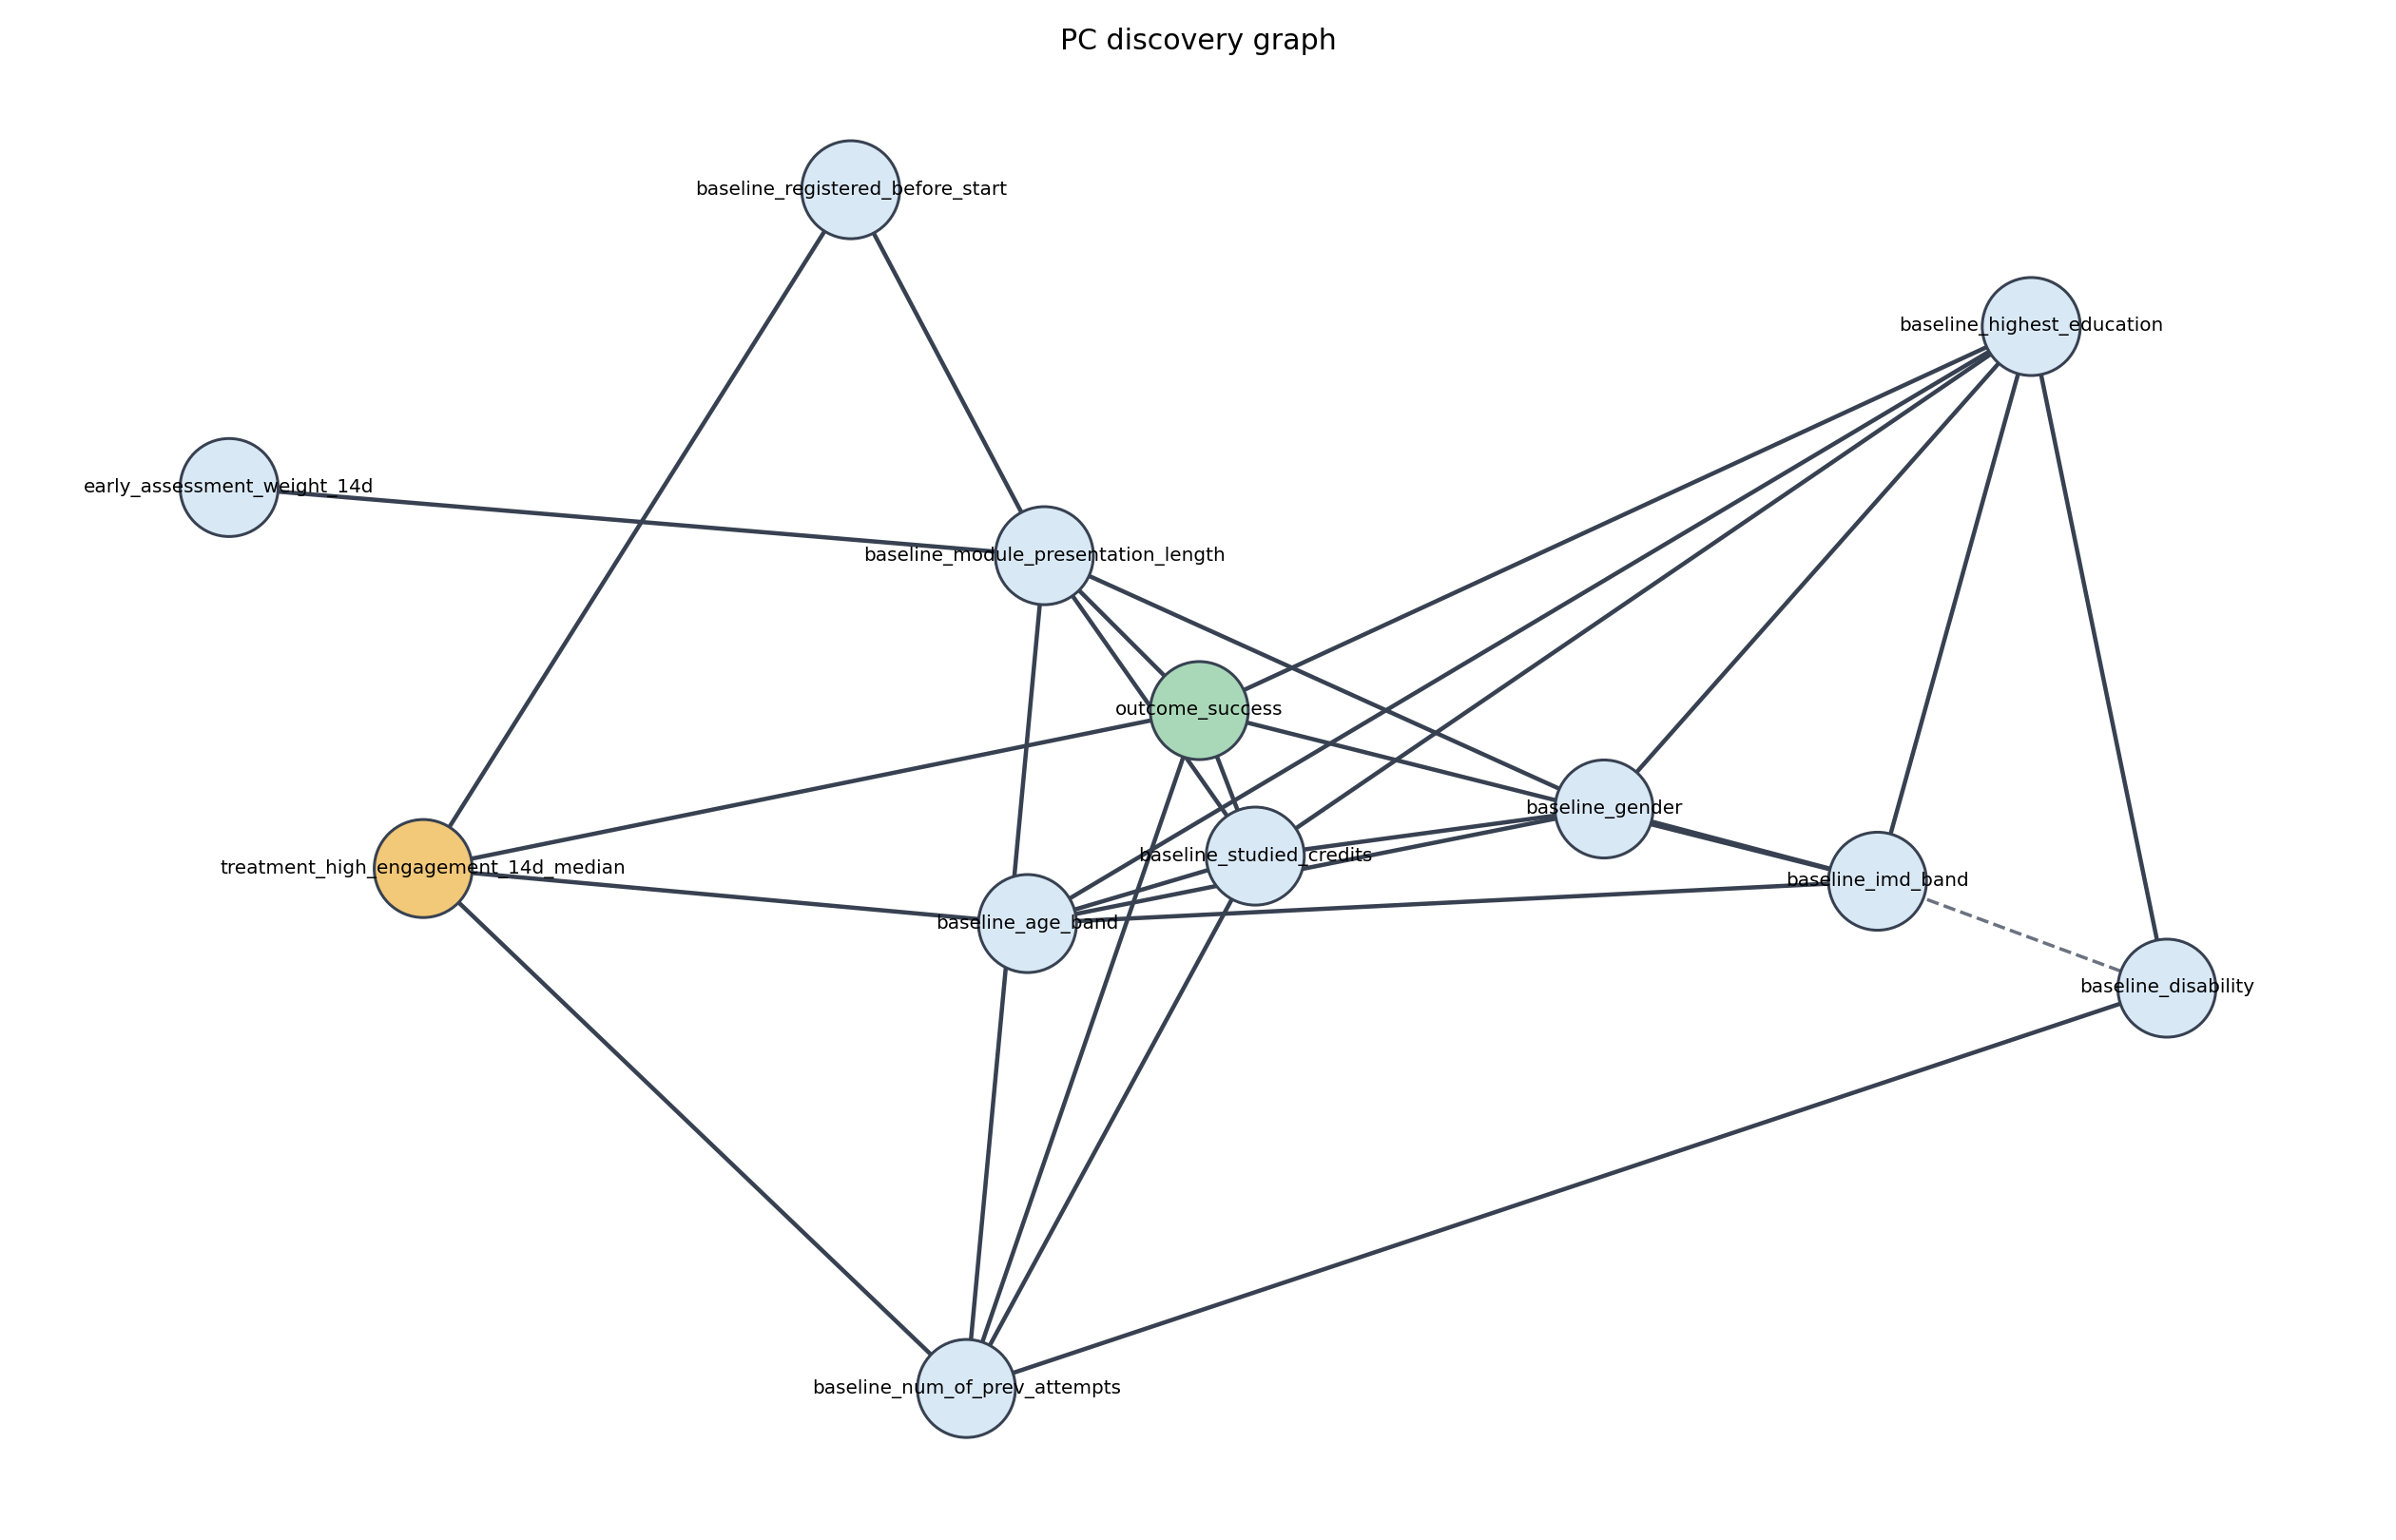

FCI


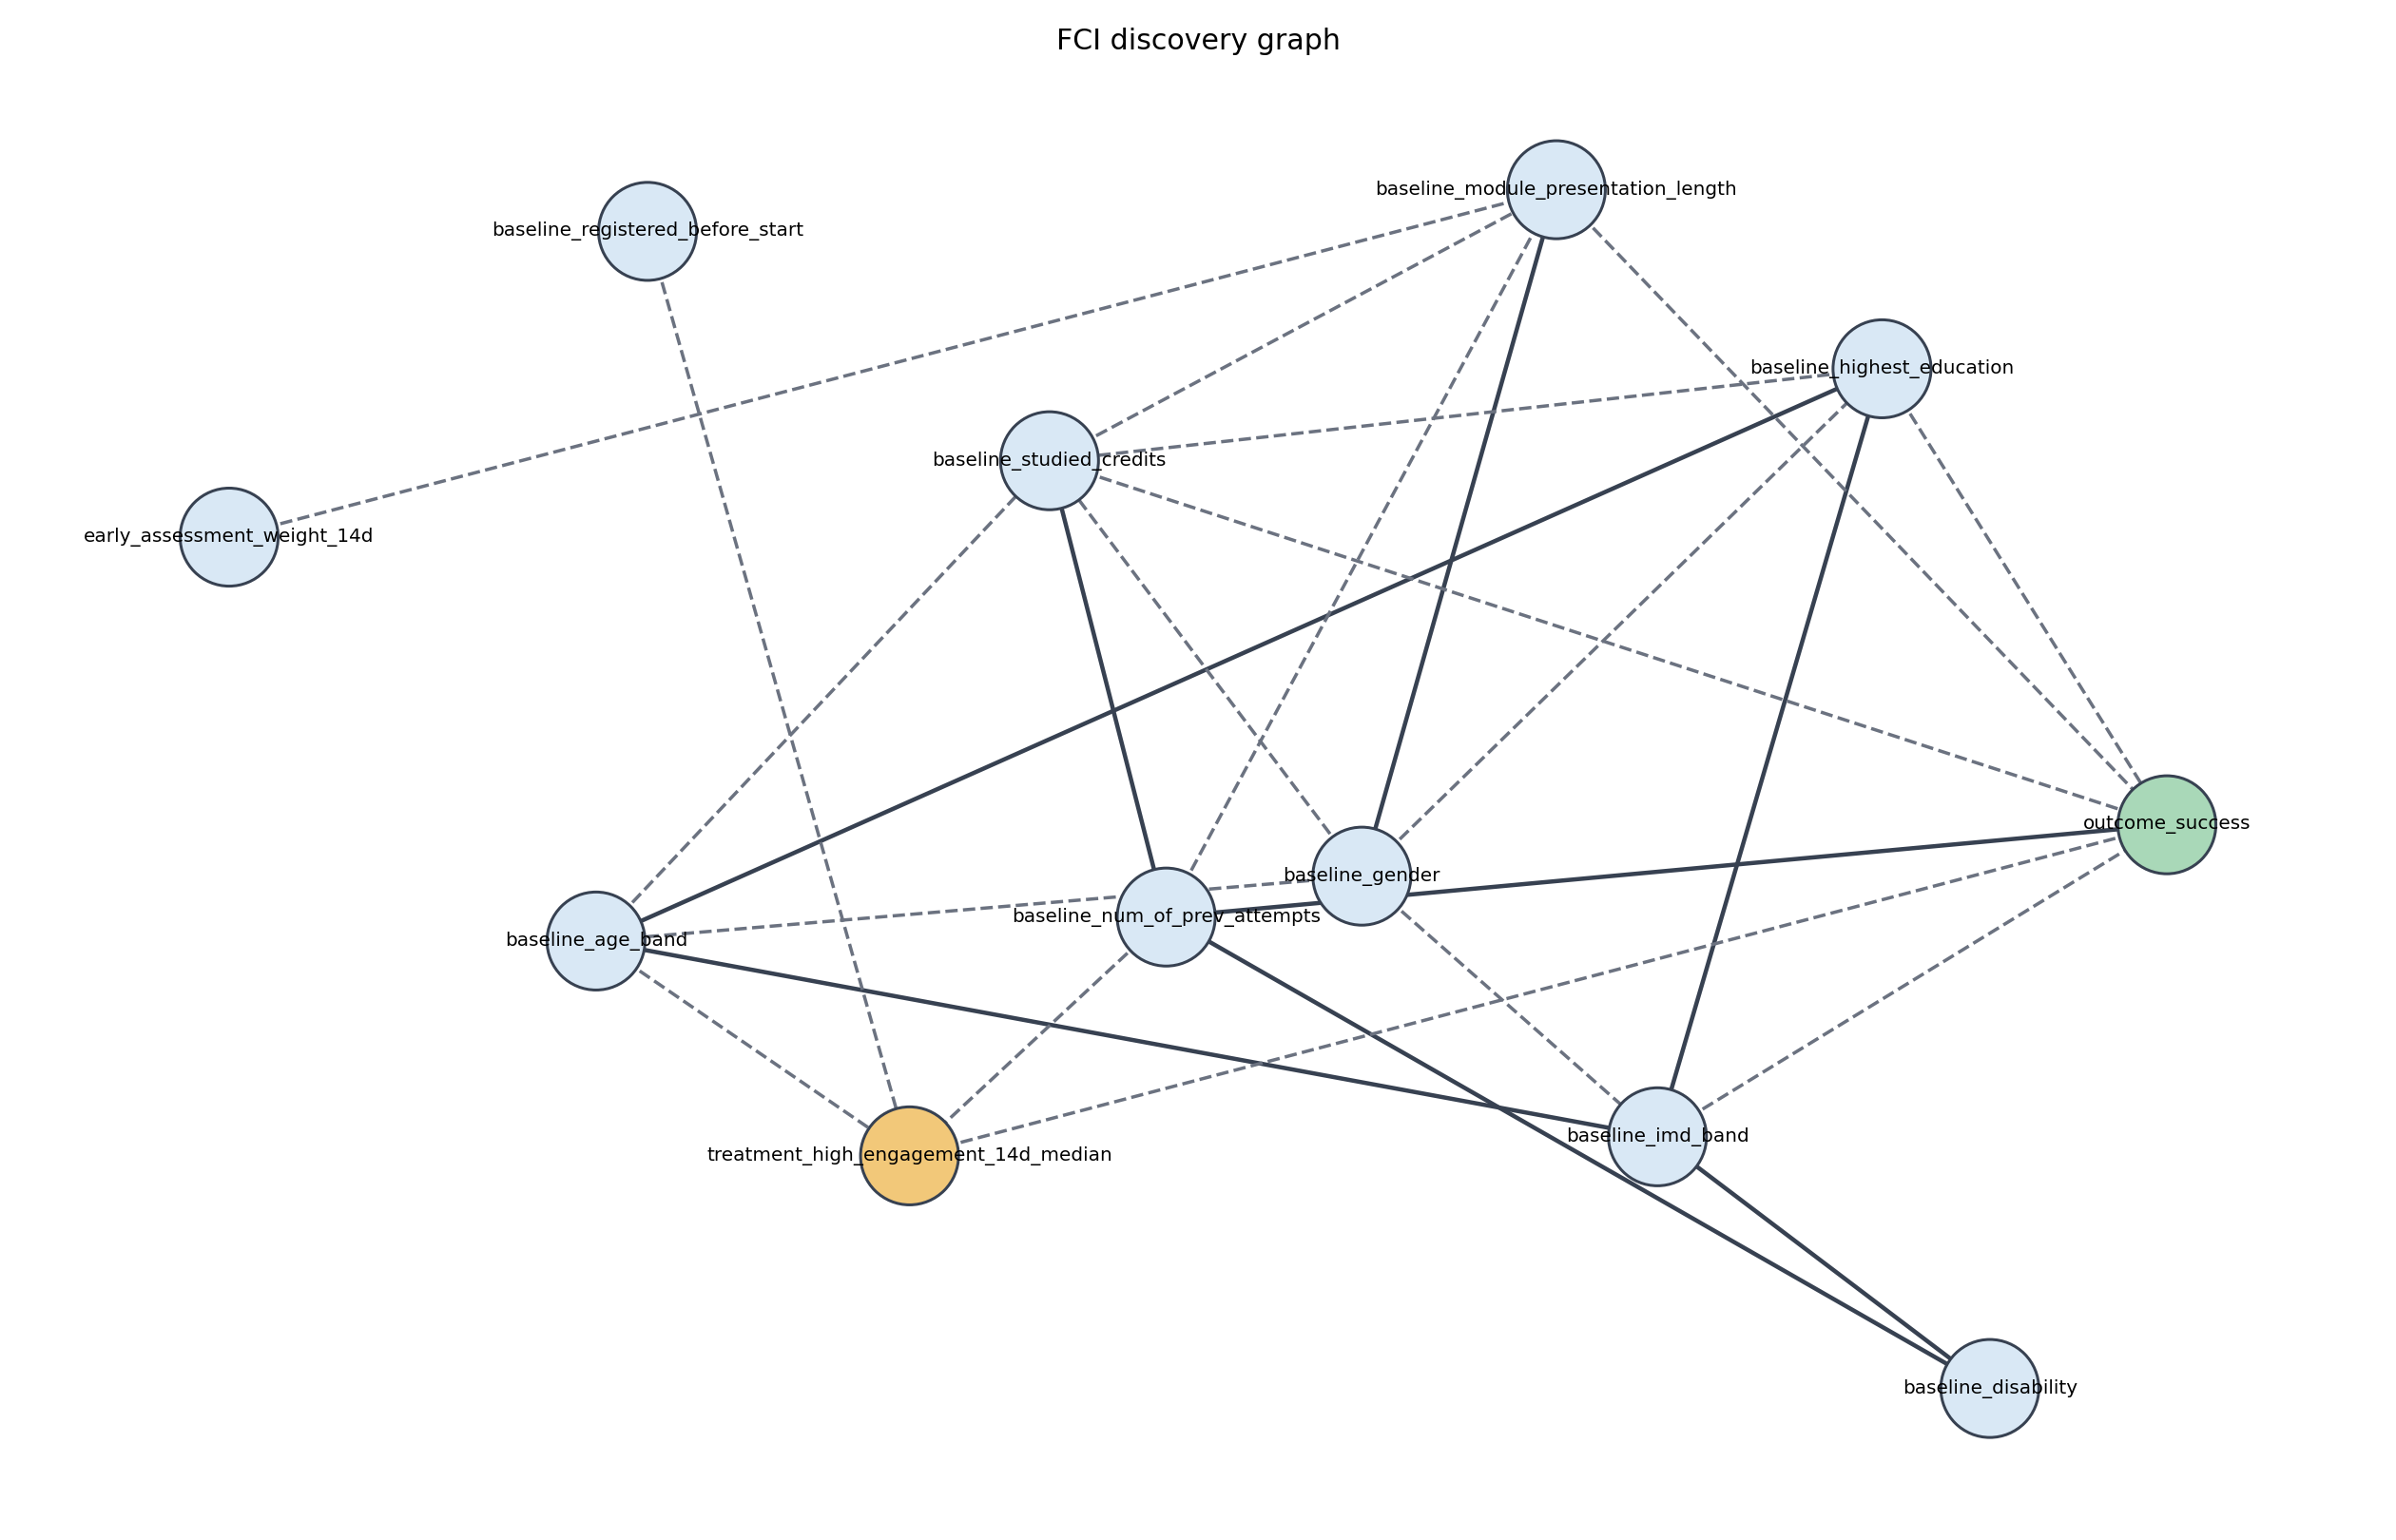

GES


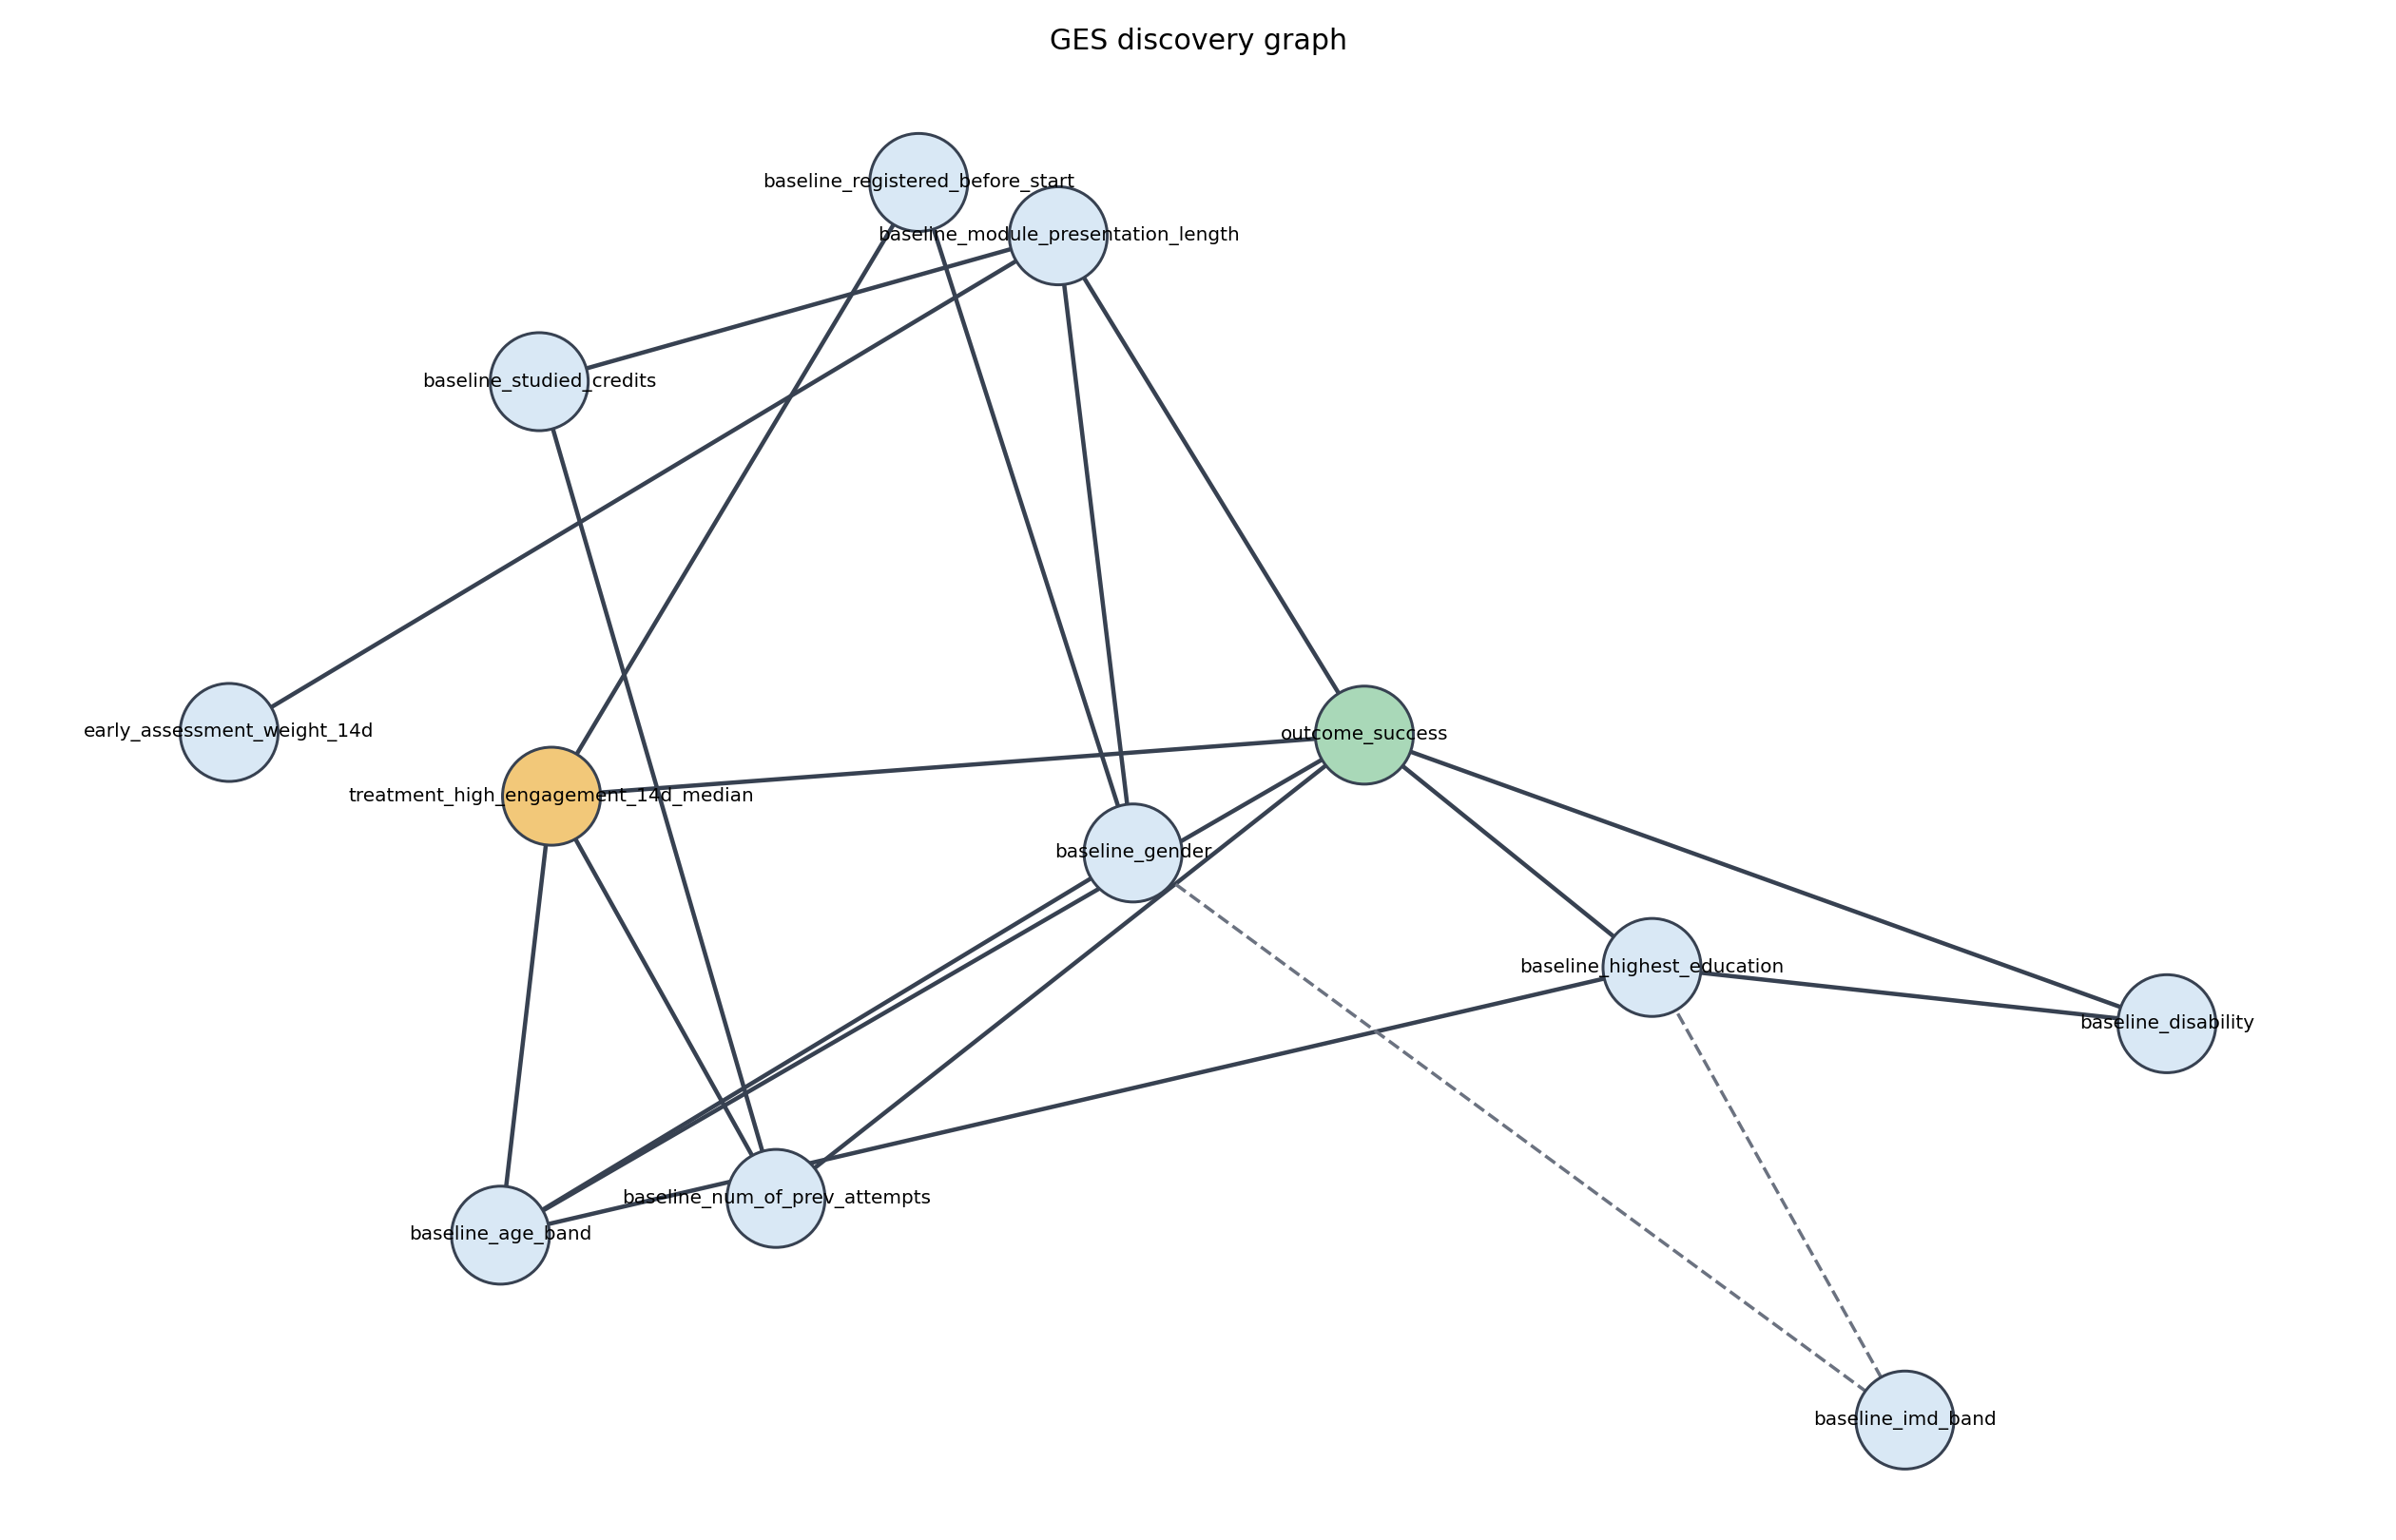

In [13]:
for method in ["pc", "fci", "ges"]:
    figure_path = FIGURES_DIR / f"discovery_{method}.png"
    if figure_path.exists():
        print(method.upper())
        display(Image(filename=str(figure_path)))
    else:
        print(f"{method.upper()} figure not found: {figure_path}")

## Generated Discovery Summary

In [14]:
if DISCOVERY_SUMMARY_PATH.exists():
    display(Markdown(DISCOVERY_SUMMARY_PATH.read_text(encoding="utf-8")))
else:
    print(f"Discovery summary not found yet: {DISCOVERY_SUMMARY_PATH}")

# Causal Discovery Summary

This file is generated from the saved causal discovery artifacts. Discovery is exploratory support for the hand-built DAG, not a replacement for the identification plan.

## Scope and preprocessing

- Analytic rows: 28128.
- Variables: baseline_gender, baseline_age_band, baseline_highest_education, baseline_imd_band, baseline_disability, baseline_num_of_prev_attempts, baseline_studied_credits, baseline_registered_before_start, baseline_module_presentation_length, early_assessment_weight_14d, treatment_high_engagement_14d_median, outcome_success.
- Mixed variables were discretized before discovery: ordinal mappings for age, education, and IMD; category codes for nominal/binary fields; quantile bins for studied credits; ordered state codes for low-cardinality numeric fields.
- PC and FCI used chi-square conditional independence tests with alpha 0.01; GES used BDeu scoring on the same discrete matrix.

## Method status

| method | status | seconds | edges | note |
| --- | --- | ---: | ---: | --- |
| pc | success | 5.369 | 27 |  |
| fci | success | 3.788 | 25 |  |
| ges | success | 10.017 | 19 |  |

## What discovery supports

- `baseline_age_band` -- `outcome_success` appeared in ges and matches the hand-built DAG skeleton.
- `baseline_age_band` -- `treatment_high_engagement_14d_median` appeared in fci, ges, pc and matches the hand-built DAG skeleton; repeated-subsample pc frequency 0.70.
- `baseline_disability` -- `outcome_success` appeared in ges and matches the hand-built DAG skeleton.
- `baseline_highest_education` -- `outcome_success` appeared in fci, ges, pc and matches the hand-built DAG skeleton; repeated-subsample fci frequency 0.75.
- `baseline_imd_band` -- `outcome_success` appeared in fci, pc and matches the hand-built DAG skeleton.
- `baseline_module_presentation_length` -- `early_assessment_weight_14d` appeared in fci, ges, pc and matches the hand-built DAG skeleton; repeated-subsample pc frequency 1.00.
- `baseline_module_presentation_length` -- `outcome_success` appeared in fci, ges, pc and matches the hand-built DAG skeleton.
- `baseline_num_of_prev_attempts` -- `outcome_success` appeared in fci, ges, pc and matches the hand-built DAG skeleton; repeated-subsample ges frequency 0.80.
- `baseline_num_of_prev_attempts` -- `treatment_high_engagement_14d_median` appeared in fci, ges, pc and matches the hand-built DAG skeleton.
- `baseline_registered_before_start` -- `treatment_high_engagement_14d_median` appeared in fci, ges, pc and matches the hand-built DAG skeleton.
- `baseline_studied_credits` -- `outcome_success` appeared in fci, pc and matches the hand-built DAG skeleton.
- `outcome_success` -- `treatment_high_engagement_14d_median` appeared in fci, ges, pc and matches the hand-built DAG skeleton; repeated-subsample pc frequency 1.00.

## What discovery does not establish

- It does not establish causal truth, because the OULAD cohort remains observational and motivation, time availability, outside support, and similar constructs are unmeasured.
- It does not justify adjusting for post-treatment variables or changing the primary adjustment set.
- It does not make orientations definitive; PC, FCI, and GES orientations here are treated as exploratory, especially for undirected, circle, or bidirected endpoints.
- It does not remove sensitivity to preprocessing choices; the algorithms used a reduced, discretized representation of mixed variables.

## Noisy or unstable findings

- `baseline_imd_band` -- `outcome_success` in pc had edge frequency 0.55.
- `baseline_gender` -- `baseline_studied_credits` in ges had edge frequency 0.55.
- `baseline_registered_before_start` -- `treatment_high_engagement_14d_median` in ges had edge frequency 0.50.
- `baseline_imd_band` -- `outcome_success` in fci had edge frequency 0.45.
- `baseline_num_of_prev_attempts` -- `outcome_success` in pc had edge frequency 0.35.
- `baseline_num_of_prev_attempts` -- `outcome_success` in fci had edge frequency 0.30.
- `baseline_gender` -- `baseline_studied_credits` in pc had edge frequency 0.25.
- `baseline_num_of_prev_attempts` -- `treatment_high_engagement_14d_median` in pc had edge frequency 0.20.
- `baseline_age_band` -- `baseline_imd_band` in fci had edge frequency 0.20.
- `baseline_disability` -- `outcome_success` in ges had edge frequency 0.20.
- `baseline_age_band` -- `baseline_gender` in ges had edge frequency 0.20.
- `baseline_age_band` -- `baseline_studied_credits` in fci had edge frequency 0.15.

## Hand-built DAG edges not recovered

- `baseline_disability` -> `treatment_high_engagement_14d_median` was in the hand-built DAG but not recovered as a skeleton edge.
- `baseline_gender` -> `outcome_success` was in the hand-built DAG but not recovered as a skeleton edge.
- `baseline_gender` -> `treatment_high_engagement_14d_median` was in the hand-built DAG but not recovered as a skeleton edge.
- `baseline_highest_education` -> `treatment_high_engagement_14d_median` was in the hand-built DAG but not recovered as a skeleton edge.
- `baseline_imd_band` -> `treatment_high_engagement_14d_median` was in the hand-built DAG but not recovered as a skeleton edge.
- `baseline_module_presentation_length` -> `treatment_high_engagement_14d_median` was in the hand-built DAG but not recovered as a skeleton edge.
- `baseline_registered_before_start` -> `outcome_success` was in the hand-built DAG but not recovered as a skeleton edge.
- `baseline_studied_credits` -> `treatment_high_engagement_14d_median` was in the hand-built DAG but not recovered as a skeleton edge.
- `early_assessment_weight_14d` -> `outcome_success` was in the hand-built DAG but not recovered as a skeleton edge.
- `early_assessment_weight_14d` -> `treatment_high_engagement_14d_median` was in the hand-built DAG but not recovered as a skeleton edge.

## Artifact inventory

- `analysis_data`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_analysis_data.parquet`
- `preprocessing_map`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_preprocessing_map.json`
- `combined_edges`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_edges.csv`
- `edges_pc`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_edges_pc.csv`
- `edges_fci`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_edges_fci.csv`
- `edges_ges`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_edges_ges.csv`
- `adjacency_pc`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_adjacency_pc.csv`
- `adjacency_fci`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_adjacency_fci.csv`
- `adjacency_ges`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_adjacency_ges.csv`
- `figure_pc`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/reports/figures/discovery_pc.png`
- `figure_fci`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/reports/figures/discovery_fci.png`
- `figure_ges`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/reports/figures/discovery_ges.png`
- `stability_edges`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_stability_edges.csv`
- `hand_dag_comparison`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_hand_dag_comparison.csv`
- `metadata`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/data/processed/discovery_run_metadata.json`
- `summary`: `/Users/shreyashreddy/Desktop/UCSD SP26/DSC 245/oulad-causal-inference/oulad-causal-inference/docs/discovery_summary.md`
